# Universität Osnabrück - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Universität Osnabrück' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/04qmmjx98' -- 'Universität Osnabrück'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Universität Osnabrück,Institute of Information Management and Inform...,https://openalex.org/W4285256727
1,not assigned,Universität Osnabrück,"Universität Osnabrück, Abteilung Berufs- und W...",https://openalex.org/W4319438938
2,not assigned,Universität Osnabrück,"Department of Biology/Chemistry, and Center fo...",https://openalex.org/W4290960210
3,not assigned,Universität Osnabrück,"Department of Structural Biology, Osnabrück Un...",https://openalex.org/W4304820621
4,not assigned,Universität Osnabrück,"Department of Physics, University of Osnabrück...",https://openalex.org/W4312296996


In [48]:
MAPPING_DICT = {
    'Fachbereich Biologie / Chemie': ['dida(c|k)ti(k|cs) (of|der) (biolog(ie|y)|chemie)', 'genetics', 'biolog(ie|y)(/| and )chemi(e|stry)', 'botan(y|ical)', 
                                      '(new|organic|neuer) material(ien|s)', '(neuro|mi(k|c)ro)biolog(ie|y)', 'chemi(e|stry)', 'electrochemical',
                                      'bioorganische', '(behavio(u)?ral|structural|cell) biology', 'nanoanalytic', 'zoology', 'biodiversity',
                                      'plant physiology', 'department of ecology', 'animal', '(department|faculty) of biology', 'bioimaging'
                                     ],
    'Fachbereich Erziehungs- und Kulturwissenschaften': ['education(al)? science', 'erziehungswissenschaft', '(school|science|institute) of education', 
                                                         '(islami(sche|c)|katholische|ev.|evangelische) theolog(ie|y)', 'vocational',
                                                         'schulpädagogik', 'sport', 'elementary education', 'musi(k|c)'
                                                        ],
    'Fachbereich Humanwissenschaften': ['kognitionswissenschaft', 'dermatolog(ie|ic|y|ische)', 'psycholog(ie|y)', 'cognitive', '(human|health) (sciences|research)',
                                        'pflegewissenschaft', 'philosophy', 'ethics and critical theories', 'new public health', 'psychotherapy',
                                        'gesundheitsforschung', 'childhood', 'nursing science', 'forschungsmethodik'
                                       ],
    'Fachbereich Kultur- und Sozialwissenschaften': ['(social|political|soil) science', 'geograph(ie|y)', 'sozial(- und kultur)?wissenschaften', 'european integration',
                                                     'conflict research', 'historisches seminar', 'department of history', 'modern history',
                                                     'neueste geschichte'
                                                    ],
    'Fachbereich Mathematik / Informatik / Physik': ['mathemati(k|cs)', '(institut|department) (für|of) (physi(k|cs)|informatik)', 'computer science', 'physi(k|cs),',
                                                     'semantic information', 'data science', 'information systems', 'digital image', 'fachbereich physik',
                                                     'software engineering', 'physics (education|department)', 'computer engineering', 'knowledge-based systems',
                                                     'artificial intelligence', 'applied algebra'
                                                    ],
    'Fachbereich Rechtswissenschaften': ['(gesellschafts|straf|völker|europa|wirtschafts)recht', 'faculty of law', 'legal studies'],
    'Fachbereich Sprach- und Literaturwissenschaft': ['germanistik', 'linguistics', 'american studies', 'latinistics', '(romance|latin) (studies|languages)'],
    'Fachbereich Wirtschaftswissenschaften': ['wirtschaftsinformatik', 'business administration', 'accounting', 'economic education', 'business and economics',
                                              'wirtschaftswissenschaften', 'banking and finance', '(international|empirical) economic', 'department of economics',
                                              '(innovation|information) management', 'economic department'
                                             ],
    'Institut für Migrationsforschung und Interkulturelle Studien (IMIS)': ['(imis)', 'migrationsforschung', 'migration research'],
    'Institut für Umweltsystemforschung': ['environmental systems (science|research|economics)'],
    #'Universitätsbibliothek': [],
    #'Zentrum für Informationsmanagement und Virtuelle Lehre': [],
    #'Zentrum für Lehrerbildung (ZLB)': []
}

In [49]:
with open('./mapping_tables_fak/uosnabrueck.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [50]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [51]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [52]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Fachbereich Mathematik / Informatik / Physik,Universität Osnabrück,Institute of Information Management and Inform...,https://openalex.org/W4285256727
1,None,Universität Osnabrück,"Universität Osnabrück, Abteilung Berufs- und W...",https://openalex.org/W4319438938
2,Fachbereich Biologie / Chemie,Universität Osnabrück,"Department of Biology/Chemistry, and Center fo...",https://openalex.org/W4290960210
3,Fachbereich Biologie / Chemie,Universität Osnabrück,"Department of Structural Biology, Osnabrück Un...",https://openalex.org/W4304820621
4,Fachbereich Mathematik / Informatik / Physik,Universität Osnabrück,"Department of Physics, University of Osnabrück...",https://openalex.org/W4312296996
...,...,...,...,...
5720,None,Universität Osnabrück,Universität Osnabrück,https://openalex.org/W3046955377
5721,None,Universität Osnabrück,Universität Osnabrück,https://openalex.org/W3131215780
5722,None,Universität Osnabrück,Universität Osnabrück,https://openalex.org/W3153975123
5723,None,Universität Osnabrück,Universität Osnabrück,https://openalex.org/W2903446642


In [53]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()[200:220]

array(['University of Osnabrück, Albrechtstr. 28a, 49076 Osnabrück, Germany',
       'Universität Osnabrück,                         Deutschland',
       'Department of Neurology, University Hospital Münster, Germany; Department of Neurology and Neurorehabilitation, Klinikum Osnabrueck, Academic Teaching Hospital of the University of Muenster, Osnabrueck, Germany',
       'Universität Osnabrück,                   Deutschland',
       'University of Osnabruck,MTDML, IMM,Osnabruck,Germany',
       'MTDML, IMM, University of Osnabruck, Osnabruck, Germany',
       'University of Osnabrueck = Osnabrueck Universität (Neuer Graben/Schloss, 49074 Osnabrück - Germany)',
       'Health Informatics Research Group, Osnabrück University of AS  Osnabrück Germany',
       'University of Münster, Epilepsy Center Münster-Osnabrück, Department of Neurology with Institute of Translational Neurology, Münster, Germany',
       'University of Münster, Epilepsy Center Münster-Osnabrück, Department of Neurolo

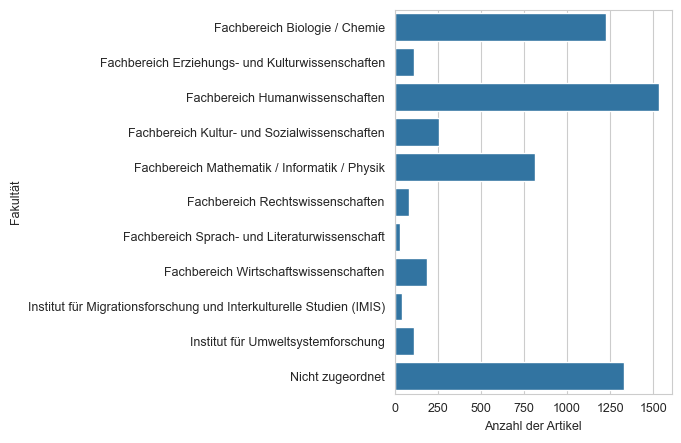

In [54]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [55]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.7680349344978166

In [64]:
MAPPING_DICT_DEPT = {
    'Fachbereich Biologie / Chemie': {
        'Abteilung Mitochondriale Dynamik': ['mitochondriale', 'mitochondrial dynamics'],
        'Arbeitsgruppe Bioanalytische Chemie': ['bioanalytische chemie', 'bioanalytical chemistry'],
        'Arbeitsgruppe Biochemie': ['biochemi(e|stry)'],
        'Arbeitsgruppe Biodiversität und Landschaftsökologie': ['biodiversität', 'biodiversity'],
        'Arbeitsgruppe Biologiedidaktik': ['biologiedidaktik', 'biology didactics', 'didactics of biology'],
        'Arbeitsgruppe Biophysik': ['biophysics'],
        'Arbeitsgruppe Botanik': ['botan(ik|y)'],
        'Arbeitsgruppe Chemische Biologie der Membranen': ['chemische biologie', 'membrane biology'],
        #'Arbeitsgruppe Dynamik der multizellulären Signalgebung': [],
        'Arbeitsgruppe Genetik': ['genetics', 'ag genetik'],
        'Arbeitsgruppe Mikrobiologie': ['(?<!molekulare) mi(k|c)robiolog(ie|y)'],
        'Arbeitsgruppe Molekulare Infektionsbiologie': ['molecular infection biology'],
        'Arbeitsgruppe Molekulare Mikrobiologie': ['molekulare mikrobiologie'],
        'Arbeitsgruppe Molekulare Zellbiologie': ['molecular cell biology'],
        'Arbeitsgruppe Neurobiologie': ['neurobiolog(ie|y)'],
        'Arbeitsgruppe Strukturbiologie': ['structural biology'],
        'Arbeitsgruppe Tierphysiologie': ['animal (nutrition|husbandry)', 'animal physiology', 'tierphysiologie'],
        'Arbeitsgruppe Zoologie-Entwicklungsbiologie': ['developmental biology', 'zoolog(ie|y)'],
        'Arbeitsgruppe Ökologie': ['department of ecology', 'ecology section'],
        'Botanischer Garten': ['botani(sch|cal)'],
        #'Center for Advanced Light Microscopy': [],
        'Institut für Chemie neuer Materialien': ['chemie neuer materialien', 'chemistry of new materials', 'organic materials chemistry', 'chemistry education',
                                                  'didactics of chemistry', 'didaktik der chemie', 'chemiedidaktik', 'bioorganische chemie', '(inorganic|physical) chemistry',
                                                  'electrochemical'
                                                 ],
        'Labor für zelluläre Kommunikation': ['cellular communication'],
        'Lehrstuhl Pflanzenphysiologie': ['plant physiology'],
        'Verhaltensbiologie': ['verhaltensbiologie', 'behavio(u)?ral biology'],
        'Center of Cellular Nanoanalytics': ['cent(er|re) (of|for) cellular nanoanalytic', 'cellnanos', 'bioimaging'] # selbst ergänzt
    },
    'Fachbereich Erziehungs- und Kulturwissenschaften': {
        'Fachgebiet Sachuntericht': ['sachuntericht'],
        'Institut für Erziehungswissenschaft': ['erziehungswissenschaft', 'educational science', 'schulpädagogik', 'vocational education'],
        'Institut für Evangelische Theologie': ['ev(.|angelische) theologie'],
        'Institut für Islamische Theologie (IIT)': ['islamische theologie', 'islamic theology'],
        'Institut für Katholische Theologie': ['katholische theologie'],
        'Institut für Musikwissenschaft und Musikpädagogik': ['musikwissenschaft'],
        'Institut für Sport- und Bewegungswissenschaften': ['bewegungswissenschaften', 'sport(s)? and movement', 'human movement'],
        'Studiengang für Islamische Religionspädagogik (IRP)': ['islamische religionspädagogik'],
    },
    'Fachbereich Humanwissenschaften': {
        'Institut für Gesundheitsforschung und Bildung (IGB)': ['gesundheitsforschung', 'dermatolog(i|y)', 'health (research|science)', 'public health', 'nursing science',
                                                                'pflegewissenschaft'
                                                               ],
        'Institut für Kognitionswissenschaft': ['cognitive science', 'kognitionswissenschaft'],
        'Institut für Philosophie': ['philosoph(ie|y)'],
        'Institut für Psychologie': ['psycholog(ie|y)', 'early childhood', 'psychotherapy', 'forschungsmethodik'],
    },
    'Fachbereich Kultur- und Sozialwissenschaften': {
        'Fachgebiet Kunst / Kunstpädagogik': ['kunst'],
        'Fachgebiet Textiles Gestalten': ['textiles gestalten'],
        'Historisches Seminar': ['historisches seminar', 'modern history', 'neueste geschichte', 'department of history'],
        'Institut für Geographie': ['geograph(ie|y)'],
        'Institut Sozialwissenschaften': ['(department|institute) (of|for) social science', 'sozialwissenschaften', 'political science', 'international relations'],
        'Interdisziplinäres Institut für Kulturgeschichte der Frühen Neuzeit': ['neuzeit'],
        'Kunsthistorisches Institut': ['kunsthistorisches institut'],
    },
    'Fachbereich Mathematik / Informatik / Physik': {
        'Fach Physik': ['physi(k|cs)'],
        'Institut für Informatik': ['informatik', 'computer science', '(software|computer) engineering', 'information (management|system)', 'artificial',
                                    'remote sensing', 'knowledge-based'
                                   ],
        'Institut für Mathematik': ['mathemati(c|k)'],
    },
    'Fachbereich Rechtswissenschaften': {
        'Center for International Research on Chinese Law and Economics (CIRCLE)': ['chinese law'],
        'Institut für Europäische Rechtswissenschaft': ['europarecht', 'internationales strafrecht', 'verwaltungswissenschaften', 'european', 'international law'],
        'Institut für Finanz- und Steuerrecht': ['steuerrecht'],
        'Institut für Handels- und Wirtschaftsrecht': ['handels- und wirtschaftsrecht', 'bürgerliches recht', 'unternehmens- und wirtschaftsrecht'],
        'Institut für Kommunalrecht': ['kommunalrecht'],
        'Institut für Staats-, Verwaltungs- und Wirtschaftsrecht (ISVWR)': ['institut für staats'],
        'Institut für Verfahrensrecht und allgemeine Verfahrensvergleichung': ['verfahrensrecht'],
        'Institut für Wirtschaftsstrafrecht': ['wirtschaftsstrafrecht', 'steuerstrafrecht'],
    },
    'Fachbereich Sprach- und Literaturwissenschaft': {
        'Institut für Anglistik / Amerikanistik': ['english', 'british', 'anglistik', 'amerikanistik'],
        'Institut für Germanistik (IfG)': ['germanistik'],
        'Institut für Romanistik / Latinistik': ['roman(ce|istics)'],
    },
    'Fachbereich Wirtschaftswissenschaften': {
        'Fach Betriebswirtschaftslehre (BWL)': ['betriebswirtschaftslehre', 'bwl', 'banking', 'innovation management'],
        'Fach Volkswirtschaftslehre (VWL)': ['volkswirtschaftslehre', 'vwl', 'international economic'],
        'Fach Wirtschaftsinformatik (WI)': ['wirtschaftsinformatik', 'business informatics'],
        'Institut für Empirische Wirtschaftsforschung': ['wirtschaftsforschung', 'empiri(sch|cal)'],
        'Institut für Informationsmanagement und Unternehmensführung (IMU)': ['informationsmanagement'],
        'Institut für Umweltsystemforschung': ['environmental', 'umwelt'] #selbst ergänzt
    }
}

In [65]:
with open('./mapping_tables_dept/uosnabrueck.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [66]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [67]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fachbereich Wirtschaftswissenschaften', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fachbereich Wirtschaftswissenschaften']['raw_affiliation_string'].apply(map_dept, 
                                                                                    faculty='Fachbereich Wirtschaftswissenschaften')

In [68]:
df_with_inst[(df_with_inst['fak_name'] == 'Fachbereich Wirtschaftswissenschaften') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[0:]

array(['School of Business Administration and Economics Osnabrück University  Osnabrück Germany',
       'University of Osnabrück Department of Economics and the Leeds University Business School',
       'School of Business Administration and Economics, Osnabrueck University, Osnabrueck, Germany',
       'Osnabrück University, School of Business Administration and Economics, Rolandstr. 8, 49078 Osnabrück, Germany',
       'School of Business Administration and Economics, University of Osnabrück, Osnabrück, Germany',
       'School of Business Administration and Economics, IUSF Research Centre - Osnabrueck University',
       'Faculty of Business and Economics University of Osnabrueck  Osnabrück Germany',
       'Department of Economics, Osnabrueck University, Rolandstr. 8, Osnabrueck, 49069 Germany',
       'Department of Economics Osnabrueck University Rolandstr. 8 Osnabrueck 49069 Germany',
       'School of Business Administration and Economics, Osnabruck University',
       'School

In [69]:
df_with_inst[df_with_inst['fak_name'] == 'Fachbereich Wirtschaftswissenschaften'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Fach Betriebswirtschaftslehre (BWL),14
1,Fach Volkswirtschaftslehre (VWL),1
2,Fach Wirtschaftsinformatik (WI),79
3,Institut für Empirische Wirtschaftsforschung,15
4,Institut für Umweltsystemforschung,32
5,NaN,47


In [70]:
df_with_inst[df_with_inst['fak_name'] == 'Fachbereich Wirtschaftswissenschaften']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
41,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,School of Business Administration and Economic...,https://openalex.org/W4298029077,Institut für Umweltsystemforschung
131,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,Informationsmanagement und Wirtschaftsinformat...,https://openalex.org/W4214917813,Fach Wirtschaftsinformatik (WI)
132,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,Informationsmanagement und Wirtschaftsinformat...,https://openalex.org/W4214917813,Fach Wirtschaftsinformatik (WI)
140,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,"Institute of Empirical Economic Research, Osna...",https://openalex.org/W4290237505,Institut für Empirische Wirtschaftsforschung
153,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,Alexander von Humboldt-Professorship of Enviro...,https://openalex.org/W4225713883,Institut für Umweltsystemforschung
...,...,...,...,...,...
5018,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,Fachgebiet Informationsmanagement und Wirtscha...,https://openalex.org/W3207797944,Fach Wirtschaftsinformatik (WI)
5023,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,"Osnabrueck University, School of Business Admi...",https://openalex.org/W3004111396,None
5052,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,Fachgebiet Informationsmanagement und Wirtscha...,https://openalex.org/W3091783648,Fach Wirtschaftsinformatik (WI)
5053,Fachbereich Wirtschaftswissenschaften,Universität Osnabrück,Fachgebiet Informationsmanagement und Wirtscha...,https://openalex.org/W3091783648,Fach Wirtschaftsinformatik (WI)
